In [1]:
#loading ATAC h5ad file and RNAseq h5ad file
import anndata
from anndata import AnnData

ATACdata = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/ATAC/zf_multiome_atlas_full_ATAC_v1_release.h5ad", backed="r")
ATACdata.obs

RNAdata = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/RNA/zf_multiome_atlas_full_RNA_v1_release.h5ad")
RNAdata.obs

,developmental_stage,dataset,zebrafish_anatomy_ontology_class,zebrafish_anatomy_ontology_class_coarse,timepoint,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_nc,pct_counts_nc
AAACAGCCACCTAAGC-1_1,15somites,TDR118,epidermis,epidermis,16hpf,2317,6522.0,160.0,2.453235,726.0,11.131555
AAACAGCCAGGGAGGA-1_1,15somites,TDR118,pronephros,pronephros,16hpf,2319,6100.0,245.0,4.016393,1051.0,17.229508
AAACAGCCATAGACCC-1_1,15somites,TDR118,hindbrain,hindbrain,16hpf,3467,12581.0,779.0,6.191877,2542.0,20.205071
AAACATGCAAACTCAT-1_1,15somites,TDR118,spinal_cord,spinal_cord,16hpf,2145,5642.0,265.0,4.696916,1075.0,19.053527
AAACATGCAAGGACCA-1_1,15somites,TDR118,neural_optic2,neural_optic,16hpf,838,2691.0,181.0,6.726124,732.0,27.201784
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTGTTCCCTCAGT-1_7,10somites,TDR128,tail_bud,tail_bud,14hpf,1281,3079.0,114.0,3.702501,572.0,18.577460
TTTGTTGGTACCTTAC-1_7,10somites,TDR128,lateral_plate_mesoderm,lateral_plate_mesoderm,14hpf,2441,6276.0,179.0,2.852135,962.0,15.328235
TTTGTTGGTATTGAGT-1_7,10somites,TDR128,neural_posterior,neural_posterior,14hpf,1164,2377.0,74.0,3.113168,217.0,9.129154
TTTGTTGGTGCGCGTA-1_7,10somites,TDR128,endocrine_pancreas,endocrine_pancreas,14hpf,811,1750.0,54.0,3.085714,182.0,10.400000


In [2]:
#checking the max and min percentages of mt genes in the ATAC data
print("Max percentage of MT genes in RNA data:", RNAdata.obs["pct_counts_mt"].max())
print("Min percentage of MT genes in RNA data:", RNAdata.obs["pct_counts_mt"].min())

Max percentage of MT genes in RNA data: 16.584500098599882
Min percentage of MT genes in RNA data: 0.11827321111768185


In [3]:
#Subsetting the data to only include the cells that are included in the pseudobulk RNA-seq matrix

cells = []
with open("/home/fgsasse_lrs_1/Downloads/BA/BA_data/ATAC/cell_id.txt", "r") as f:
    for line in f:
        cells.append(line.strip())

cells


filtered_ATdata = ATACdata[cells, :]
filtered_Rdata = RNAdata[cells, :]

#check dimension of both datasets
filtered_ATdata.shape, filtered_Rdata.shape



((93063, 640834), (93063, 32057))

In [4]:
#checking if the *coarse* annotaions of cell types in the ATAC data match the cell types in the pseudobulk RNA-seq matrix (Rdata)
filtered_Rdata.obs[	"zebrafish_anatomy_ontology_class_coarse"].unique(), filtered_ATdata.obs["annotation_ML_coarse"].unique()
filtered_Rdata.obs[	"zebrafish_anatomy_ontology_class_coarse"].unique() == filtered_ATdata.obs["annotation_ML_coarse"].unique()


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True])

In [5]:
#now checking if the same cells are annotated with the same cell type in both datasets by comparing cell IDs (row indices) for each coarse category

# Get coarse categories that exist in both datasets
common_categories = set(filtered_Rdata.obs["zebrafish_anatomy_ontology_class_coarse"].unique()) & set(filtered_ATdata.obs["annotation_ML_coarse"].unique())
common_categories

print("Comparing cell IDs for common coarse categories:")
total_matching = 0
for category in sorted(common_categories):
    rna_cells = set(filtered_Rdata.obs[filtered_Rdata.obs["zebrafish_anatomy_ontology_class_coarse"] == category].index)
    atac_cells = set(filtered_ATdata.obs[filtered_ATdata.obs["annotation_ML_coarse"] == category].index)
    
    matching = len(rna_cells & atac_cells)
    only_rna = len(rna_cells - atac_cells)
    only_atac = len(atac_cells - rna_cells)
    
    total_matching += matching
   
    print(f"Category '{category}': {matching} matching cells", end="")
    if only_rna > 0:
        print(f", {only_rna} only in RNA", end="")
    if only_atac > 0:
        print(f", {only_atac} only in ATAC", end="")
    print()  

print(f"Total matching cells across all categories: {total_matching}")

Comparing cell IDs for common coarse categories:
Category 'NMPs': 1799 matching cells
Category 'PSM': 4650 matching cells
Category 'differentiating_neurons': 2050 matching cells
Category 'endocrine_pancreas': 3031 matching cells
Category 'endoderm': 1853 matching cells
Category 'enteric_neurons': 636 matching cells
Category 'epidermis': 9490 matching cells
Category 'fast_muscle': 1942 matching cells
Category 'floor_plate': 3365 matching cells
Category 'hatching_gland': 728 matching cells
Category 'heart_myocardium': 2837 matching cells
Category 'hemangioblasts': 1133 matching cells
Category 'hematopoietic_vasculature': 1588 matching cells
Category 'hindbrain': 2577 matching cells
Category 'lateral_plate_mesoderm': 1800 matching cells
Category 'midbrain_hindbrain_boundary': 5525 matching cells
Category 'muscle': 1328 matching cells
Category 'neural': 405 matching cells
Category 'neural_crest': 5195 matching cells
Category 'neural_floor_plate': 4469 matching cells
Category 'neural_optic'

In [6]:
#checking which of the more specific cell type annotations in the Rdata is missing in the ATAC data
ctrna =filtered_Rdata.obs["zebrafish_anatomy_ontology_class"].unique()
ctatac = filtered_ATdata.obs["annotation_ML_coarse"].unique() 

missing_in_ctatac = set(ctrna) - set(ctatac)
print(f"Categories in Rdata cell types but missing in ctatac:\n{missing_in_ctatac}")
print(f"\nTotal missing: {len(missing_in_ctatac)}")

Categories in Rdata cell types but missing in ctatac:
{'floor_plate2', 'epidermis4', 'pronephros2', 'epidermis3', 'midbrain_hindbrain_boundary2', 'neural_crest2', 'neural_optic2', 'epidermis2'}

Total missing: 8


In [7]:
#checking the number of cells with the specific annotation "zebrafish_anatomy_ontology_class" in Rdata
for ct in missing_in_ctatac:
    count = (filtered_Rdata.obs["zebrafish_anatomy_ontology_class"] == ct).sum()
    print(f"Number of cells with specific annotation '{ct}': {count}")

Number of cells with specific annotation 'floor_plate2': 1048
Number of cells with specific annotation 'epidermis4': 1763
Number of cells with specific annotation 'pronephros2': 805
Number of cells with specific annotation 'epidermis3': 1840
Number of cells with specific annotation 'midbrain_hindbrain_boundary2': 3550
Number of cells with specific annotation 'neural_crest2': 2213
Number of cells with specific annotation 'neural_optic2': 4468
Number of cells with specific annotation 'epidermis2': 2560


In [8]:
#checking if the cells with more specific annotations ("zebrafish_anatomy_ontology_class" ) are in the same coarse cell type category  
for ct in missing_in_ctatac:
    coarse_category = filtered_Rdata.obs.loc[filtered_Rdata.obs["zebrafish_anatomy_ontology_class"] == ct, "zebrafish_anatomy_ontology_class_coarse"].unique()
    print(f"Specific cell type '{ct}' belongs to coarse category: {coarse_category}")


Specific cell type 'floor_plate2' belongs to coarse category: ['floor_plate']
Categories (31, object): ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', ..., 'pronephros', 'somites', 'spinal_cord', 'tail_bud']
Specific cell type 'epidermis4' belongs to coarse category: ['epidermis']
Categories (31, object): ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', ..., 'pronephros', 'somites', 'spinal_cord', 'tail_bud']
Specific cell type 'pronephros2' belongs to coarse category: ['pronephros']
Categories (31, object): ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', ..., 'pronephros', 'somites', 'spinal_cord', 'tail_bud']
Specific cell type 'epidermis3' belongs to coarse category: ['epidermis']
Categories (31, object): ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', ..., 'pronephros', 'somites', 'spinal_cord', 'tail_bud']
Specific cell type 'midbrain_hindbrain_boundary2' belongs to coarse category: ['midbrain_hindbrain_boundary']


## QC
Nucleocome signal: mononucleosomal (149-294 bp) / nucleosome-free (<147 bp) fragments
Fragment size distribution typically reflects nucleosome binding pattern showing enrichment around values corresponding to fragments bound to a single nucleosome (between 147 bp and 294 bp) as well as nucleosome-free fragments (shorter than 147 bp).
- successful ATAC-seq experiment exhibits typically a depletion of DNA fragments with lengths that are multiples of 149 bp, so the lower the nucleosome signal, the better quality of data set *NucleosomeSignal*

Transcriptional start site (TSS) enrichment: mean Tn5 insertion count (±500 bp around the TSS)/ mean Tn5 insertions in flanking regions (+900 to +1000 bp and −900 to −1000 bp)
TSS enrichment indicates how strongly accesisble chromatin is enriched around gene start sites
- high score indicates clear chromatin accessibility signal; good quality cell *TSSEnrichment*

/home/fgsasse_lrs_1/miniforge3/envs/mybaenv/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


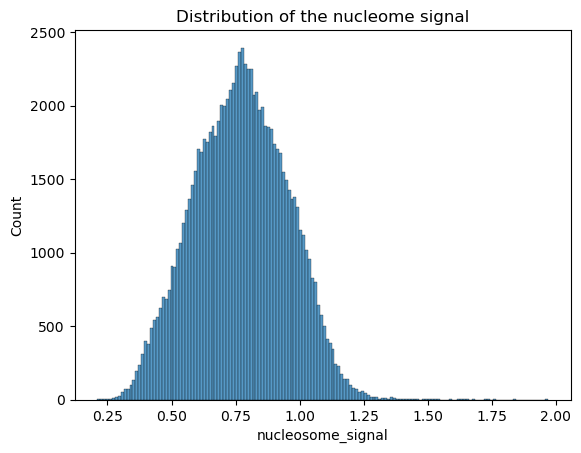

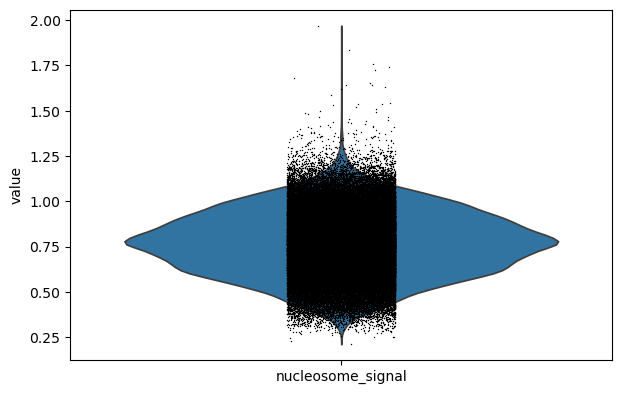

In [4]:
#Plotting the distribution of nucleosome signals in the filtered ATAC data
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import seaborn as sns
import muon as mu

# Import a module with ATAC-seq-related functions
from muon import atac as ac

sns.histplot(filtered_data.obs, x="nucleosome_signal")
plt.title("Distribution of the nucleome signal")
plt.show()

# Alternatively as a violin plot (uncomment to plot)
sc.pl.violin(filtered_data, "nucleosome_signal")
#sc.pl.violin(filtered_data, "nucleosome_percentile", groupby="annotation_ML_coarse", title="Nucleosome signal percentile by cell type")

High-quality cells congregate in the top-left or top-center region, showing *high TSS enrichment* and relatively *low to moderate nucleosome signal*.

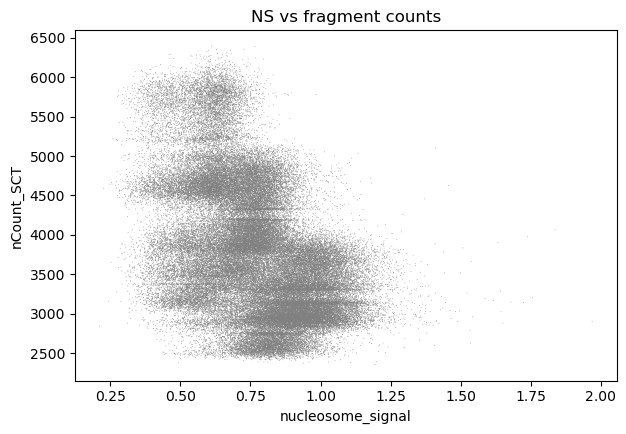

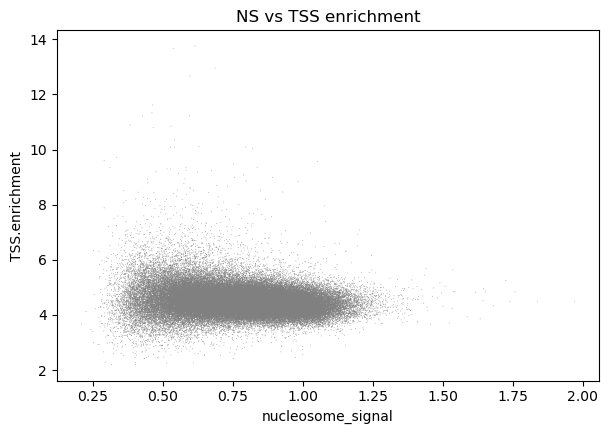

In [5]:
#Plotting the relationship between nucleosome signal and fragment counts and TSS enrichment
sc.pl.scatter(filtered_data, x="nucleosome_signal", y="nCount_SCT", title="NS vs fragment counts")
sc.pl.scatter(filtered_data, x="nucleosome_signal", y="TSS.enrichment", title="NS vs TSS enrichment")

## Dimension Reduction
Latent Semantic Indexing (LSI)
If we apply Principal Component Analysis on this sparse insertion counts matrix and plot the top two principal components, we wouldn't obtain the desired result because the sparsity causes high inter-cell similarity at all of the 0 positions. To get around this issue, we use a layered dimensionality reduction approach. First, we use Latent Semantic Indexing (LSI), an approach from natural language processing that was originally designed to assess document similarity based on word counts. 
The resultant term frequency-inverse document frequency (TF-IDF) matrix reflects how important a word (aka region/peak) is to a document (aka sample). Then, through a technique called singular value decomposition (SVD), the most valuable information across samples is identified and represented in a lower dimensional space. *RunSVD*
Then Uniform Manifold Approximation and Projection (UMAP) is used to visualize the data. *RunUMAP*
- The first LSI component was excluded from each analysis as it typically captures sequencing depth (technical variation) and was highly correlated with the total number of counts for the cell (?)

In [6]:
sc.pl.umap(
    filtered_data,
    color="leiden_1",
    add_outline=True,
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,
    frameon=False,
    title="leiden_1 clustering on UMAP",
    palette="Set1"
)

KeyError: "Could not find 'umap' or 'X_umap' in .obsm"

In [7]:
#number of categories in the annotation_ML_coarse column
filtered_data.obs.annotation_ML_coarse.nunique()

31